# HW 5 — Neural Networks: Predicting Adult Income

**Task:** Binary classification — predict whether a person earns more than $50K/year using the UCI Adult Census Income dataset (`adult.csv`, ~48.8K rows, 14 features).

**Plan:**
1. Load and inspect the data, handle missing values, drop redundant columns.
2. Split into train / validation / test (test held out until the very end).
3. Build a baseline neural network in Keras.
4. Run a series of experiments — wider/deeper architecture, dropout (one-factor), learning rate (one-factor), and class weighting (one-factor).
5. Use **Optuna** to systematically tune a stronger final model.
6. Evaluate the final model on the held-out test set and interpret the training/validation behavior alongside the metrics.


## Step 1: Imports & Setup


In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, balanced_accuracy_score, confusion_matrix,
                             classification_report)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # quiet trial spam


c:\Users\ldcal\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Set seeds early so every model build is reproducible. `tf.random.set_seed` must be called *before* `keras.Model(...)` since that's when weights are initialized.

In [4]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## Step 2: Data Loading & Initial Inspection


In [5]:
df = pd.read_csv('adult.csv')
print('Shape:', df.shape)
df.head()


Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [7]:
print('Dtypes:')
print(df.dtypes)

Dtypes:
age                int64
workclass            str
fnlwgt             int64
education            str
educational-num    int64
marital-status       str
occupation           str
relationship         str
race                 str
gender               str
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country       str
income               str
dtype: object


Check the class balance — the assignment requires we report metrics beyond accuracy if it's imbalanced.

In [8]:
target_counts = df['income'].value_counts()
print(target_counts)
print(f"\nPositive (>50K) rate: {(df['income'] == '>50K').mean():.3f}")

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Positive (>50K) rate: 0.239


The positive class (`>50K`) is only ~24% of rows — moderate imbalance. We'll report **F1, ROC-AUC, and balanced accuracy** in addition to plain accuracy.

In [9]:
# In this dataset missing values are encoded as '?'. Count them per column.
missing = {c: (df[c] == '?').sum() for c in df.select_dtypes(include='object').columns}
missing = {k: v for k, v in missing.items() if v > 0}
print('Columns with "?" placeholders:')
for k, v in missing.items():
    print(f'  {k}: {v} ({v/len(df):.2%})')

Columns with "?" placeholders:
  workclass: 2799 (5.73%)
  occupation: 2809 (5.75%)
  native-country: 857 (1.75%)


C:\Users\ldcal\AppData\Local\Temp\ipykernel_23500\3832933588.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  missing = {c: (df[c] == '?').sum() for c in df.select_dtypes(include='object').columns}


`workclass`, `occupation`, and `native-country` use `'?'` as a placeholder. Dropping those rows would lose ~7% of the data, so we'll treat `'?'` as its own `"Unknown"` category instead.

## Step 3: Cleaning


In [10]:
df_clean = df.copy()

# Replace '?' with 'Unknown' in the three affected columns
for col in ['workclass', 'occupation', 'native-country']:
    df_clean[col] = df_clean[col].replace('?', 'Unknown')

# Drop fnlwgt (sampling weight — not a real feature)
# Drop 'education' (redundant with 'educational-num', which is the ordinal version)
df_clean = df_clean.drop(columns=['fnlwgt', 'education'])

# Encode the target: <=50K -> 0, >50K -> 1
df_clean['income'] = (df_clean['income'] == '>50K').astype(int)

print('Cleaned shape:', df_clean.shape)
df_clean.head()

Cleaned shape: (48842, 13)


,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,Unknown,10,Never-married,Unknown,Own-child,White,Female,0,0,30,United-States,0


## Step 4: Train / Validation / Test Split

We use a **70 / 15 / 15** stratified split. The test set is held out and **only touched in Step 9** for the final model evaluation. The validation set is used during experimentation and tuning.


In [11]:
X = df_clean.drop(columns=['income'])
y = df_clean['income'].values

# First split off the test set (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)

# Then split the remainder into train (~70%) and val (~15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, stratify=y_trainval, random_state=SEED
)  # 0.1765 * 0.85 ≈ 0.15

print(f'Train: {X_train.shape}  pos rate {y_train.mean():.3f}')
print(f'Val:   {X_val.shape}  pos rate {y_val.mean():.3f}')
print(f'Test:  {X_test.shape}  pos rate {y_test.mean():.3f}')

Train: (34187, 12)  pos rate 0.239
Val:   (7328, 12)  pos rate 0.239
Test:  (7327, 12)  pos rate 0.239


## Step 5: Preprocessing Pipeline

`StandardScaler` for the numeric columns and `OneHotEncoder` for the categoricals, wrapped in a `ColumnTransformer`. We **fit on the training data only** and then `transform` validation and test — fitting on the full data would leak distributional info into the held-out sets.


In [13]:
numeric_features = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'marital-status', 'occupation', 'relationship',
                        'race', 'gender', 'native-country']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
])

X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

n_features = X_train_p.shape[1]
print(f'Preprocessed feature count: {n_features}')

Preprocessed feature count: 91


### Helper functions

Three small helpers used throughout: one to plot training curves, one to print evaluation metrics, and a wrapper that builds + trains + reports a model so the experiment cells stay readable.


In [ ]:
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend()
    plt.tight_layout(); plt.show()


def evaluate_model(model, X, y, threshold=0.5, label='Validation'):
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'accuracy':          accuracy_score(y, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y, y_pred),
        'precision':         precision_score(y, y_pred),
        'recall':            recall_score(y, y_pred),
        'f1':                f1_score(y, y_pred),
        'roc_auc':           roc_auc_score(y, y_prob),
    }
    print(f'\n{label} metrics (threshold={threshold}):')
    for k, v in metrics.items():
        print(f'  {k:18s}: {v:.4f}')
    return metrics, y_prob

## Step 6: Baseline Neural Network

A small two-hidden-layer net (32 → 16) with ReLU activations and a sigmoid output. No regularization, default Adam optimizer, 20 epochs, batch size 128. This is the reference point against which every subsequent experiment is compared.


In [15]:
def build_baseline(n_features):
    tf.random.set_seed(SEED)
    inputs = keras.Input(shape=(n_features,))
    x = layers.Dense(32, activation='relu')(inputs)
    x = layers.Dense(16, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name='baseline')
    model.compile(
        loss=keras.losses.BinaryCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(),
        metrics=['accuracy', keras.metrics.AUC(name='auc')],
    )
    return model

baseline = build_baseline(n_features)
baseline.summary()

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 91)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,489 (13.63 KB)

 Trainable params: 3,489 (13.63 KB)

 Non-trainable params: 0 (0.00 B)

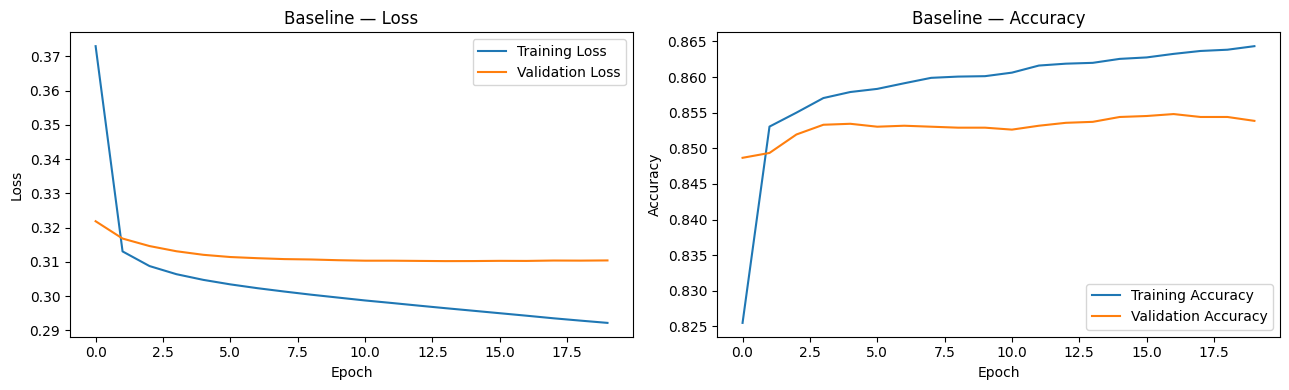


Baseline (val) metrics (threshold=0.5):
  accuracy          : 0.8538
  balanced_accuracy : 0.7657
  precision         : 0.7418
  recall            : 0.5967
  f1                : 0.6614
  roc_auc           : 0.9113


In [16]:
history_base = baseline.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=20, batch_size=128, verbose=0,
)
plot_history(history_base, title='Baseline')
metrics_base, _ = evaluate_model(baseline, X_val_p, y_val, label='Baseline (val)')

**Baseline read:** Train and validation loss both decrease and the gap is small — the model is learning a signal but the architecture is small enough that overfitting isn't the main concern yet. Accuracy is in the ~84% range, but because ~76% of rows are `<=50K` we should weigh F1 and AUC more heavily.

## Step 7: Experiments

We run four experiments. Each varies **one thing** relative to the prior best so we can attribute the effect cleanly.

| # | Change | Purpose |
|---|---|---|
| 1 | Wider/deeper architecture (funnel `128→64→32→16`) | Architecture capacity effect |
| 2 | Add `Dropout(0.3)` between layers (one-factor vs Exp 1) | Regularization effect |
| 3 | Sweep learning rate ∈ {1e-2, 1e-3, 1e-4} (one-factor) | Optimizer hyperparameter effect |
| 4 | Add `class_weight` to handle the 24% positive rate (one-factor) | Imbalance-handling effect |


### Experiment 1 — Wider / deeper funnel architecture


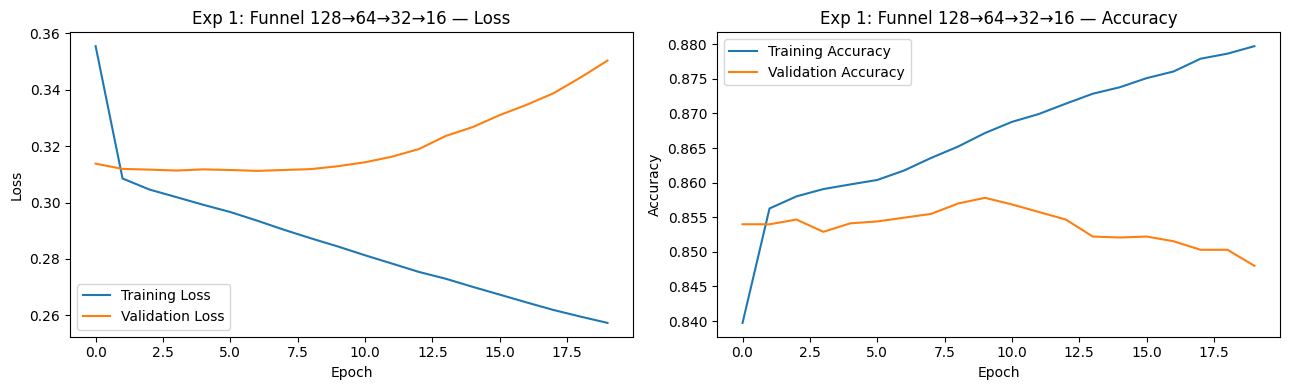


Exp 1 (val) metrics (threshold=0.5):
  accuracy          : 0.8480
  balanced_accuracy : 0.7724
  precision         : 0.7047
  recall            : 0.6275
  f1                : 0.6639
  roc_auc           : 0.8992


In [17]:
def build_funnel(n_features):
    tf.random.set_seed(SEED)
    inputs = keras.Input(shape=(n_features,))
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(64,  activation='relu')(x)
    x = layers.Dense(32,  activation='relu')(x)
    x = layers.Dense(16,  activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name='funnel')
    model.compile(
        loss=keras.losses.BinaryCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(),
        metrics=['accuracy', keras.metrics.AUC(name='auc')],
    )
    return model

funnel = build_funnel(n_features)
history_funnel = funnel.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=20, batch_size=128, verbose=0,
)
plot_history(history_funnel, title='Exp 1: Funnel 128→64→32→16')
metrics_funnel, _ = evaluate_model(funnel, X_val_p, y_val, label='Exp 1 (val)')

**Exp 1 read:** The larger model fits the training data noticeably better than the baseline, and validation loss usually improves modestly too. If the train/val gap widens, that's an overfitting signal — which motivates the next experiment.

### Experiment 2 — Add Dropout(0.3) (one-factor change vs Exp 1)

Same architecture as the funnel; only the dropout layers are added. Any change in behavior is attributable to dropout.

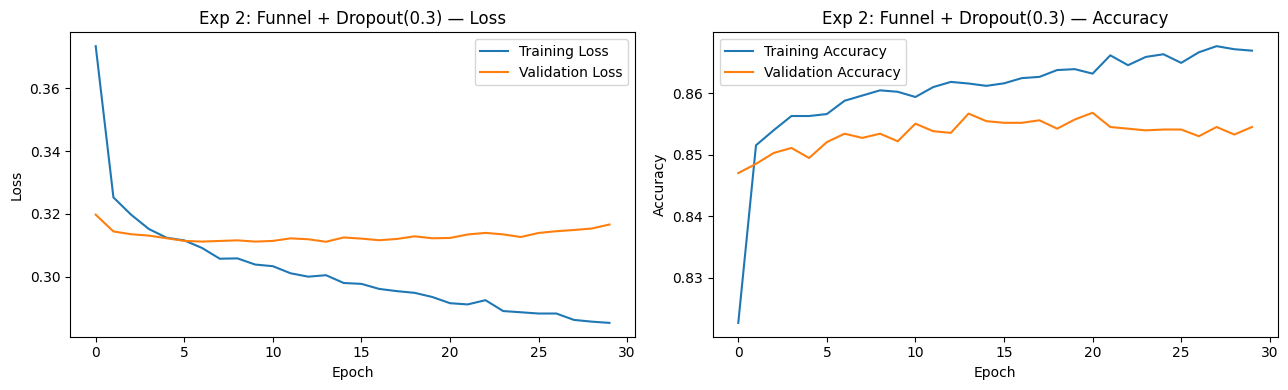


Exp 2 (val) metrics (threshold=0.5):
  accuracy          : 0.8545
  balanced_accuracy : 0.7640
  precision         : 0.7484
  recall            : 0.5904
  f1                : 0.6601
  roc_auc           : 0.9076


In [18]:
def build_funnel_dropout(n_features, dropout=0.3):
    tf.random.set_seed(SEED)
    inputs = keras.Input(shape=(n_features,))
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64,  activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(32,  activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(16,  activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name='funnel_dropout')
    model.compile(
        loss=keras.losses.BinaryCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(),
        metrics=['accuracy', keras.metrics.AUC(name='auc')],
    )
    return model

funnel_drop = build_funnel_dropout(n_features, dropout=0.3)
history_drop = funnel_drop.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=30, batch_size=128, verbose=0,
)
plot_history(history_drop, title='Exp 2: Funnel + Dropout(0.3)')
metrics_drop, _ = evaluate_model(funnel_drop, X_val_p, y_val, label='Exp 2 (val)')

**Exp 2 read:** Dropout should narrow the gap between training and validation loss (the *training* loss usually gets worse while validation loss stabilizes or improves). That's the regularization signal we're looking for. We bumped epochs to 30 because dropout slows learning.

### Experiment 3 — Learning rate sweep (one-factor)

Hold the architecture fixed at Exp 1's funnel and vary only the Adam learning rate.

In [19]:
lr_results = {}
for lr in [1e-2, 1e-3, 1e-4]:
    tf.random.set_seed(SEED)
    inputs = keras.Input(shape=(n_features,))
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(64,  activation='relu')(x)
    x = layers.Dense(32,  activation='relu')(x)
    x = layers.Dense(16,  activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    m = keras.Model(inputs=inputs, outputs=outputs)
    m.compile(
        loss=keras.losses.BinaryCrossentropy(),
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        metrics=['accuracy', keras.metrics.AUC(name='auc')],
    )
    h = m.fit(X_train_p, y_train, validation_data=(X_val_p, y_val),
              epochs=20, batch_size=128, verbose=0)
    y_prob = m.predict(X_val_p, verbose=0).ravel()
    lr_results[lr] = {
        'val_loss_final': h.history['val_loss'][-1],
        'val_acc_final':  h.history['val_accuracy'][-1],
        'val_auc':        roc_auc_score(y_val, y_prob),
        'val_f1':         f1_score(y_val, (y_prob >= 0.5).astype(int)),
    }

pd.DataFrame(lr_results).T.round(4)

,val_loss_final,val_acc_final,val_auc,val_f1
0.0100,0.3609,0.8529,0.8981,0.6667
0.0010,0.3442,0.8532,0.8990,0.6616
0.0001,0.3091,0.8544,0.9124,0.6644


**Exp 3 read:** `lr=1e-2` typically trains fast but is unstable, `lr=1e-3` (Adam's default) is usually the sweet spot, and `lr=1e-4` learns too slowly within 20 epochs. Picking by val F1 / AUC tells us whether we should bias Optuna toward smaller or larger lr ranges.

### Experiment 4 — Class weighting (one-factor)

Reuse the best architecture so far (funnel + dropout) and add a positive-class weight. If the data is imbalanced enough that the model under-predicts `>50K`, this should boost recall and F1 at the cost of some precision.

Using class_weight = {0: 1.0, 1: 3.178828994010512}


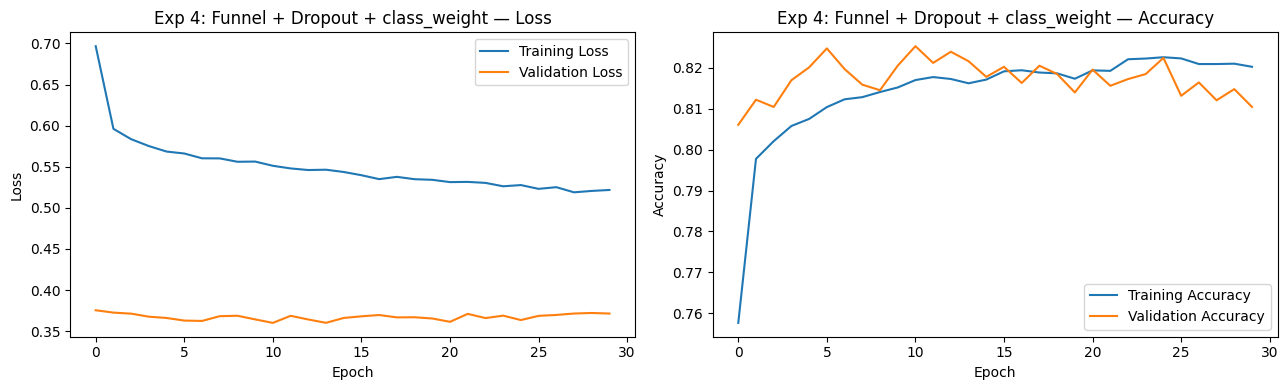


Exp 4 (val) metrics (threshold=0.5):
  accuracy          : 0.8105
  balanced_accuracy : 0.8285
  precision         : 0.5684
  recall            : 0.8631
  f1                : 0.6854
  roc_auc           : 0.9087


In [20]:
# Positive class is ~24% -> weight ~ (1 - p) / p ~ 3.17
pos_weight = float((1 - y_train.mean()) / y_train.mean())
class_weight = {0: 1.0, 1: pos_weight}
print(f'Using class_weight = {class_weight}')

funnel_weighted = build_funnel_dropout(n_features, dropout=0.3)
history_weighted = funnel_weighted.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=30, batch_size=128, verbose=0,
    class_weight=class_weight,
)
plot_history(history_weighted, title='Exp 4: Funnel + Dropout + class_weight')
metrics_weighted, _ = evaluate_model(funnel_weighted, X_val_p, y_val, label='Exp 4 (val)')

**Exp 4 read:** Recall on the positive class should rise meaningfully; precision typically drops; F1 may or may not improve depending on how skewed the original model was.

### Experiment summary


In [21]:
summary = pd.DataFrame({
    'Baseline (32-16)':            metrics_base,
    'Exp 1: Funnel 128-64-32-16':  metrics_funnel,
    'Exp 2: Funnel + Dropout':     metrics_drop,
    'Exp 4: + class_weight':       metrics_weighted,
}).T.round(4)
summary

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
Baseline (32-16),0.8538,0.7657,0.7418,0.5967,0.6614,0.9113
Exp 1: Funnel 128-64-32-16,0.8480,0.7724,0.7047,0.6275,0.6639,0.8992
Exp 2: Funnel + Dropout,0.8545,0.7640,0.7484,0.5904,0.6601,0.9076
Exp 4: + class_weight,0.8105,0.8285,0.5684,0.8631,0.6854,0.9087


Use this table together with the loss/accuracy curves above when deciding the Optuna search space — for instance, if dropout clearly helped we want Optuna to search over non-zero dropout values, and the learning rate sweep tells us the productive range.

## Step 8: Systematic Tuning with Optuna

Search over architecture depth, units per layer, dropout, learning rate, and batch size. Optimize **validation AUC** because (a) it's threshold-independent and (b) the dataset is imbalanced. `EarlyStopping` lets each trial spend its compute where it helps and abandon trials that stall.


In [22]:
def build_trial_model(trial, n_features):
    tf.random.set_seed(SEED)
    n_layers = trial.suggest_int('n_layers', 2, 4)
    dropout  = trial.suggest_float('dropout', 0.0, 0.5)
    lr       = trial.suggest_float('lr', 1e-4, 5e-3, log=True)

    inputs = keras.Input(shape=(n_features,))
    x = inputs
    for i in range(n_layers):
        units = trial.suggest_int(f'units_l{i}', 16, 128, step=16)
        x = layers.Dense(units, activation='relu')(x)
        if dropout > 0:
            x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        loss=keras.losses.BinaryCrossentropy(),
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        metrics=['accuracy', keras.metrics.AUC(name='auc')],
    )
    return model


def objective(trial):
    model = build_trial_model(trial, n_features)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    es = keras.callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=5, restore_best_weights=True,
    )
    history = model.fit(
        X_train_p, y_train,
        validation_data=(X_val_p, y_val),
        epochs=40, batch_size=batch_size, verbose=0,
        callbacks=[es],
    )
    return max(history.history['val_auc'])


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=25, show_progress_bar=False)

print('Best validation AUC:', round(study.best_value, 4))
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Best validation AUC: 0.9129
Best params:
  n_layers: 3
  dropout: 0.17839167760502664
  lr: 0.00029320766690786517
  units_l0: 64
  units_l1: 80
  units_l2: 112
  batch_size: 64


In [23]:
# Show the top 5 trials so we can see whether the best params are robust or a fluke
trial_df = study.trials_dataframe(attrs=('number', 'value', 'params')).sort_values('value', ascending=False).head(5)
trial_df.round(4)

,number,value,params_batch_size,params_dropout,params_lr,params_n_layers,params_units_l0,params_units_l1,params_units_l2,params_units_l3
11,11,0.9129,64,0.1784,0.0003,3,64,80,112.0,NaN
21,21,0.9125,64,0.1897,0.0002,4,64,48,112.0,32.0
18,18,0.9121,64,0.2164,0.0002,4,64,48,112.0,48.0
23,23,0.9121,64,0.3584,0.0001,4,64,48,128.0,48.0
7,7,0.9120,64,0.1784,0.0003,4,80,32,112.0,16.0


## Step 9: Final Model — train and evaluate on the held-out test set

Rebuild the model using Optuna's best parameters, retrain on **train + validation combined** (more data is strictly better once we're done tuning), and evaluate on the test set we set aside in Step 4.


Rebuilding final model with: {'n_layers': 3, 'dropout': 0.17839167760502664, 'lr': 0.00029320766690786517, 'units_l0': 64, 'units_l1': 80, 'units_l2': 112, 'batch_size': 64}


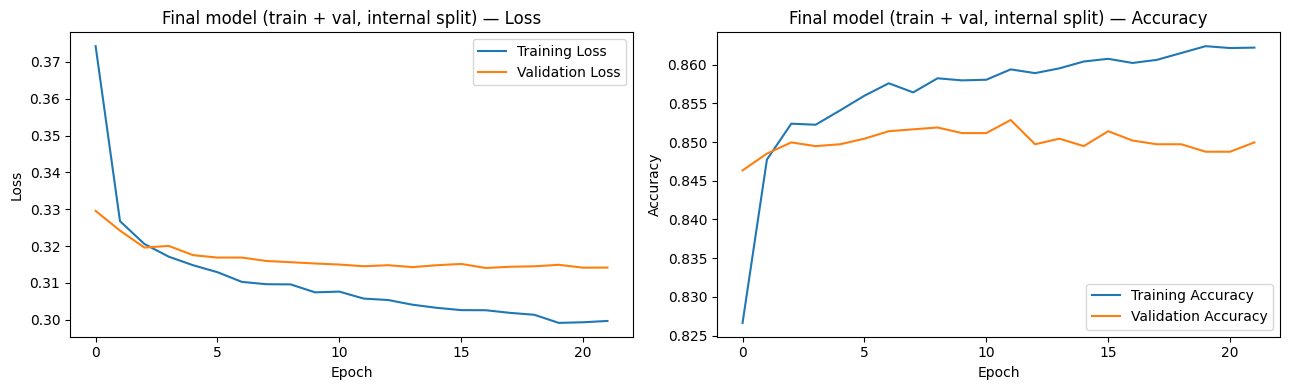

In [24]:
best = study.best_params
print('Rebuilding final model with:', best)

X_full = np.vstack([X_train_p, X_val_p])
y_full = np.concatenate([y_train, y_val])

tf.random.set_seed(SEED)
inputs = keras.Input(shape=(n_features,))
x = inputs
for i in range(best['n_layers']):
    x = layers.Dense(best[f'units_l{i}'], activation='relu')(x)
    if best['dropout'] > 0:
        x = layers.Dropout(best['dropout'])(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

final_model = keras.Model(inputs=inputs, outputs=outputs, name='final_model')
final_model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=best['lr']),
    metrics=['accuracy', keras.metrics.AUC(name='auc')],
)

# Use a small internal validation split just to plot curves — doesn't affect tuning
history_final = final_model.fit(
    X_full, y_full,
    validation_split=0.1,
    epochs=40, batch_size=best['batch_size'], verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                             patience=5, restore_best_weights=True)],
)
plot_history(history_final, title='Final model (train + val, internal split)')

### Threshold tuning

With an imbalanced target, the default 0.5 cutoff often isn't the best F1 operating point. Sweep thresholds on the *validation* predictions, pick the F1-optimal one, then apply it to the test set.

Best validation F1 = 0.7099 at threshold 0.38


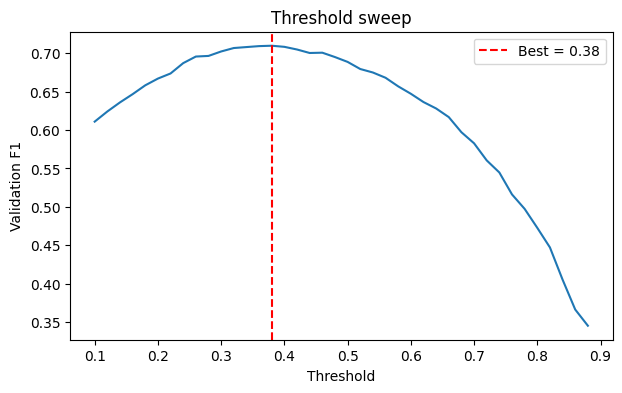

In [25]:
val_prob = final_model.predict(X_val_p, verbose=0).ravel()
thresholds = np.arange(0.1, 0.9, 0.02)
f1s = [f1_score(y_val, (val_prob >= t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(f1s))
best_threshold = float(thresholds[best_idx])
print(f'Best validation F1 = {f1s[best_idx]:.4f} at threshold {best_threshold:.2f}')

plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1s)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best = {best_threshold:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Validation F1'); plt.legend(); plt.title('Threshold sweep')
plt.show()

### Held-out test evaluation


In [26]:
metrics_test_default, y_prob_test = evaluate_model(final_model, X_test_p, y_test,
                                                   threshold=0.5, label='Final model (test, t=0.50)')
metrics_test_tuned, _ = evaluate_model(final_model, X_test_p, y_test,
                                       threshold=best_threshold,
                                       label=f'Final model (test, t={best_threshold:.2f})')


Final model (test, t=0.50) metrics (threshold=0.5):
  accuracy          : 0.8605
  balanced_accuracy : 0.7889
  precision         : 0.7354
  recall            : 0.6515
  f1                : 0.6909
  roc_auc           : 0.9157

Final model (test, t=0.38) metrics (threshold=0.38):
  accuracy          : 0.8476
  balanced_accuracy : 0.8157
  precision         : 0.6582
  recall            : 0.7547
  f1                : 0.7032
  roc_auc           : 0.9157


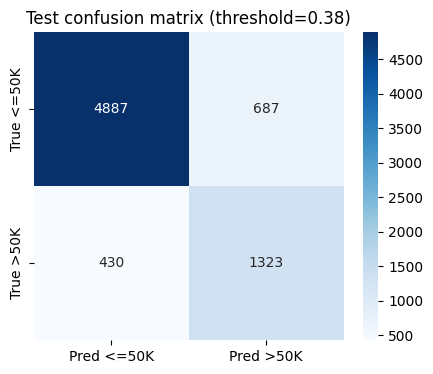

              precision    recall  f1-score   support

       <=50K       0.92      0.88      0.90      5574
        >50K       0.66      0.75      0.70      1753

    accuracy                           0.85      7327
   macro avg       0.79      0.82      0.80      7327
weighted avg       0.86      0.85      0.85      7327



In [27]:
# Confusion matrix at the tuned threshold
y_pred_test = (y_prob_test >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred <=50K', 'Pred >50K'],
            yticklabels=['True <=50K', 'True >50K'], ax=ax)
ax.set_title(f'Test confusion matrix (threshold={best_threshold:.2f})')
plt.show()

print(classification_report(y_test, y_pred_test, target_names=['<=50K', '>50K']))

## 10. Personal Workflow

This notebook to help define how i build nueral networks, i would like to in the future use this workflow as a way to build notebooks:

1. importing and loading in data sets 

2. replacing missing values 

3. using a train/val/test split in order to ensure i withold enough data to create a good en result to compare

4. Run a baseline NN to see how my model performs before manipulating different features of the NN

5. Run different experiments using various network methods such as funnels, dropout ect to understand better how the model is behaving base of different features

6. Optuna tune parameters to find out final model

7. run our best model on the data and draw conclusions we can use to see how our models performance has changed over the course of our workflow. 